# Lecture 20: Attention, Transformers & Large Language Models

In L19, we saw that word embeddings capture meaning as vectors, but each word gets one fixed vector regardless of context. Today, we'll see how **attention** solves this, and then use a real language model (SmolLM2) to generate text and answer questions.

## Setup

We'll use the `transformers` library from Hugging Face to work with **SmolLM2-135M-Instruct**, a 135-million-parameter open-weight model from Hugging Face (2024). It is small enough to load in a few seconds on Colab CPU, but large enough to follow simple instructions.

In [9]:
# Install transformers if not already available
try:
    import transformers
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import numpy as np

# Load SmolLM2-135M-Instruct (135M parameters, loads in seconds, runs on CPU)
# attn_implementation="eager" lets us inspect attention weights later
# dtype=torch.float32 so we can convert tensors to numpy (numpy doesn't support bfloat16)
print("Loading SmolLM2 model...")
model_name = "HuggingFaceTB/SmolLM2-135M-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    attn_implementation="eager",
    dtype=torch.float32,
)
model.eval()  # Set to evaluation mode
print(f"Model loaded! Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading SmolLM2 model...


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Model loaded! Parameters: 134,515,008


## 1. How the Model Sees Text: Tokens

Before generating text, let's see how the model breaks text into pieces called **tokens**. Tokens are usually common words or word fragments.

In [10]:
# Tokenize a sentence
sentence = "The quick brown fox jumps over the lazy dog"
tokens = tokenizer.encode(sentence)
print(f"Sentence: '{sentence}'")
print(f"Token IDs: {tokens}")
print(f"Number of tokens: {len(tokens)}")
print()

# Decode each token to see what it represents
print("Token breakdown:")
for token_id in tokens:
    token_text = tokenizer.decode([token_id])
    print(f"  ID {token_id:5d} -> '{token_text}'")

Sentence: 'The quick brown fox jumps over the lazy dog'
Token IDs: [504, 2365, 6354, 16438, 27003, 690, 260, 23790, 2767]
Number of tokens: 9

Token breakdown:
  ID   504 -> 'The'
  ID  2365 -> ' quick'
  ID  6354 -> ' brown'
  ID 16438 -> ' fox'
  ID 27003 -> ' jumps'
  ID   690 -> ' over'
  ID   260 -> ' the'
  ID 23790 -> ' lazy'
  ID  2767 -> ' dog'


In [11]:
# Try a longer sentence
sentence2 = "Artists like Salvador Dalí used idiosyncratic imagery, such as melting clocks, to explore the unconscious mind"
tokens2 = tokenizer.encode(sentence2)
print(f"Sentence: '{sentence2}'")
print(f"Number of tokens: {len(tokens2)}")
print()
print("Token breakdown:")
for token_id in tokens2:
    token_text = tokenizer.decode([token_id])
    print(f"  ID {token_id:5d} -> '{token_text}'")

Sentence: 'Artists like Salvador Dalí used idiosyncratic imagery, such as melting clocks, to explore the unconscious mind'
Number of tokens: 22

Token breakdown:
  ID  9393 -> 'Art'
  ID   911 -> 'ists'
  ID   702 -> ' like'
  ID 27764 -> ' Salvador'
  ID 15264 -> ' Dal'
  ID  6160 -> 'í'
  ID   804 -> ' used'
  ID 45955 -> ' idiosync'
  ID    98 -> 'r'
  ID  1442 -> 'atic'
  ID 11195 -> ' imagery'
  ID    28 -> ','
  ID   715 -> ' such'
  ID   347 -> ' as'
  ID 14004 -> ' melting'
  ID 21951 -> ' clocks'
  ID    28 -> ','
  ID   288 -> ' to'
  ID  2217 -> ' explore'
  ID   260 -> ' the'
  ID 16499 -> ' unconscious'
  ID  1945 -> ' mind'


Notice that common words like "the" and "is" are single tokens, but less common words might be split into pieces. SmolLM2's vocabulary has about 49,000 tokens.

**TODO:** Pick a sentence with a **rare word**, a name, a technical term, an emoji, or a word in another language. Tokenize it and print each token. How many tokens does the rare word break into? Are short common words always one token?

In [12]:
### BEGIN SOLUTION
my_sentence = "Mitochondria generate ATP through oxidative phosphorylation."

tokens = tokenizer.encode(my_sentence)
print(f"'{my_sentence}'")
print(f"Number of tokens: {len(tokens)}\n")
for token_id in tokens:
    print(f"  ID {token_id:5d} -> '{tokenizer.decode([token_id])}'")
### END SOLUTION

'Mitochondria generate ATP through oxidative phosphorylation.'
Number of tokens: 10

  ID 37631 -> 'Mit'
  ID 12964 -> 'ochond'
  ID  5484 -> 'ria'
  ID  5051 -> ' generate'
  ID 23961 -> ' ATP'
  ID   738 -> ' through'
  ID 21503 -> ' oxidative'
  ID 41136 -> ' phosphory'
  ID  3563 -> 'lation'
  ID    30 -> '.'


## 2. Inside the Model: How Attention Works

So far we've treated the LLM as a black box. Let's open it up and watch the **attention mechanism** at work, the same idea you saw in the slides.

The attention mechanism gives each word a new, **context-dependent** representation in three steps:

1. Compute a **score** between this word and every other word (dot product of their vectors)
2. Turn scores into **weights** with softmax
3. Replace the word's vector with a **weighted average** of all word vectors

That's it, three lines of math. Modern transformers stack this hundreds of times across many "heads," but the core operation is what we'll build below.

In [13]:
# Four toy word vectors (2D for easy visualization)
# Same example as the slides: "The spring season blooms"
words = ['the', 'spring', 'season', 'blooms']
vecs = np.array([
    [1.0, 0.0],   # the
    [2.0, 1.0],   # spring
    [2.0, 3.0],   # season
    [0.0, 2.0],   # blooms
])

# Compute attention from 'spring' (index 1) to every word -- including itself
focus = 1
scores = vecs @ vecs[focus]            # step 1: dot products with every word

# Softmax to get attention weights
exp_scores = np.exp(scores - scores.max())  # numerical stability
weights = exp_scores / exp_scores.sum()       # step 2: softmax

print(f"Attention weights from '{words[focus]}':")
for w, weight in zip(words, weights):
    bar = '#' * int(weight * 30)
    print(f"  {w:8s} ({weight:.2f}) {bar}")

# New context-aware representation = weighted average of all vectors
new_vec = (weights[:, None] * vecs).sum(axis=0)  # step 3: weighted sum
print(f"\nOriginal '{words[focus]}' vector:    {vecs[focus]}")
print(f"New context-aware vector:    {new_vec.round(2)}")

Attention weights from 'spring':
  the      (0.01) 
  spring   (0.12) ###
  season   (0.87) ##########################
  blooms   (0.01) 

Original 'spring' vector:    [2. 1.]
New context-aware vector:    [1.98 2.74]


The new "spring" vector is pulled strongly toward "season", because in this sentence, "spring" *means* a time of year. Notice that "spring" also attends to itself (its self-attention weight): this is normal. Every transformer head includes self-attention, and you'll see the same thing in the real model below.

In a different sentence ("The spring couch was soft"), "spring" would attend mostly to "couch" and get a very different vector. **The same word gets different vectors depending on context**: exactly the L19 limitation that attention solves.

**TODO:** In the toy example above we focused on `'spring'` (index 1). Change `focus` below to look at attention from a different word. Which word does it attend to most? Does the result match your intuition?

In [14]:
### BEGIN SOLUTION
focus = 2
### END SOLUTION

scores = vecs @ vecs[focus]
exp_scores = np.exp(scores - scores.max())
weights = exp_scores / exp_scores.sum()

print(f"Attention weights from '{words[focus]}':")
for w, weight in zip(words, weights):
    bar = '#' * int(weight * 30)
    print(f"  {w:8s} ({weight:.2f}) {bar}")

new_vec = (weights[:, None] * vecs).sum(axis=0)
print(f"\nOriginal '{words[focus]}' vector:    {vecs[focus]}")
print(f"New context-aware vector:    {new_vec.round(2)}")

Attention weights from 'season':
  the      (0.00) 
  spring   (0.00) 
  season   (1.00) #############################
  blooms   (0.00) 

Original 'season' vector:    [2. 3.]
New context-aware vector:    [2.   2.99]


### Attention inside SmolLM2

Now let's see what attention SmolLM2 actually computes on a tricky pronoun-resolution sentence:

> "The animal didn't cross the street because it was too tired."

A human reads "it" and figures out it refers to **animal** (the animal got tired, not the street). Does the model do something similar?

Each layer of the transformer has multiple attention "heads," each learning a different pattern. After looking through SmolLM2's 30 layers × 9 heads, **layer 13, head 8** has clearly learned a pronoun-noun resolution pattern. Let's look at it.

Attention from 'it' (layer 13, head 8):
  [ 0] 'The'        (0.07) ###
  [ 1] 'animal'     (0.73) ####################################
  [ 2] 'didn'       (0.11) #####
  [ 3] "'t"         (0.01) 
  [ 4] 'cross'      (0.01) 
  [ 5] 'the'        (0.00) 
  [ 6] 'street'     (0.01) 
  [ 7] 'because'    (0.01) 
  [ 8] 'it'         (0.05) ##
  [ 9] 'was'        (0.00) 
  [10] 'too'        (0.00) 
  [11] 'tired'      (0.00) 


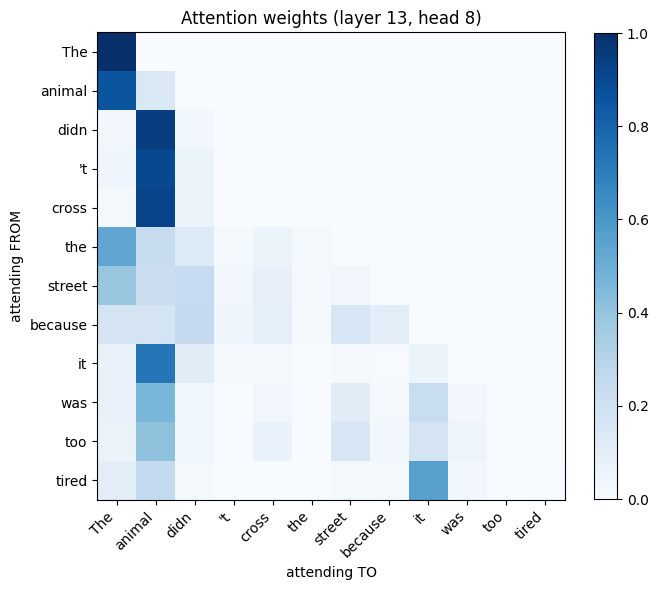

In [15]:
import matplotlib.pyplot as plt

sentence = "The animal didn't cross the street because it was too tired"
inputs = tokenizer(sentence, return_tensors='pt')
tokens = [tokenizer.decode([t]).strip() for t in inputs['input_ids'][0]]

# Run the model and ask for attention weights
with torch.no_grad():
    out = model(**inputs, output_attentions=True)

# out.attentions is a tuple of (n_layers,) each of shape (batch, heads, seq, seq)
# Pick layer 13, head 8 (specialized in pronoun -> noun)
attn = out.attentions[13][0, 8].numpy()  # shape (seq, seq)

# Show attention FROM 'it' to every other token
it_idx = tokens.index('it')
print(f"Attention from 'it' (layer 13, head 8):")
for i, t in enumerate(tokens):
    score = attn[it_idx, i]
    bar = '#' * int(score * 50)
    print(f"  [{i:2d}] {t!r:12s} ({score:.2f}) {bar}")

# Heatmap of the full attention matrix for this head
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(attn, cmap='Blues')
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right')
ax.set_yticklabels(tokens)
ax.set_xlabel("attending TO")
ax.set_ylabel("attending FROM")
ax.set_title("Attention weights (layer 13, head 8)")
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.show()

That single head has learned: **when looking at "it", attend to the closest preceding noun.** It's not perfect, different heads do different things, but you can see real linguistic structure emerging from training.

The full model has **30 layers × 9 heads = 270 different attention patterns**. Some specialize in syntax, some in semantics, some in copying tokens. Together they let the model handle context that a Markov model can't even represent.

**TODO:** Make up your own sentence with an ambiguous pronoun (a Winograd-style sentence). Does layer 13 head 8 still pick the right antecedent? Or does it default to one noun regardless of context?

In [16]:
### BEGIN SOLUTION
my_sentence = "The trophy didn't fit in the suitcase because it was too big"
target_word = 'it'
### END SOLUTION

inputs = tokenizer(my_sentence, return_tensors='pt')
my_tokens = [tokenizer.decode([t]).strip() for t in inputs['input_ids'][0]]

with torch.no_grad():
    out = model(**inputs, output_attentions=True)
attn = out.attentions[13][0, 8].numpy()

target_idx = my_tokens.index(target_word)

print(f"Attention from '{target_word}' (layer 13, head 8):")
for i, t in enumerate(my_tokens):
    score = attn[target_idx, i]
    bar = '#' * int(score * 50)
    print(f"  [{i:2d}] {t!r:12s} ({score:.2f}) {bar}")

Attention from 'it' (layer 13, head 8):
  [ 0] 'The'        (0.07) ###
  [ 1] 'trophy'     (0.54) ###########################
  [ 2] 'didn'       (0.18) ########
  [ 3] "'t"         (0.01) 
  [ 4] 'fit'        (0.02) #
  [ 5] 'in'         (0.01) 
  [ 6] 'the'        (0.00) 
  [ 7] 'suit'       (0.04) #
  [ 8] 'case'       (0.05) ##
  [ 9] 'because'    (0.01) 
  [10] 'it'         (0.06) ##
  [11] 'was'        (0.00) 
  [12] 'too'        (0.00) 
  [13] 'big'        (0.00) 


### The Punchline: Same Word, Different Vectors

The heatmap showed us *which* words each token attends to. Now let's see the payoff: does attention actually change the word's vector in a meaningful way?

Recall from L19 that word embeddings give each word **one fixed vector**. The transformer starts the same way, the input layer is a lookup table (`embedding[token_id]`) with one vector per vocabulary token. You can grab it with `model.get_input_embeddings()`. These are the *static* embeddings, exactly like L19.

But after each attention layer, every token's hidden state has been updated by its neighbors. So the **same input token** can produce **different final vectors** depending on context.

To check this, we put the word **"pound"** in two sentences and compare three vectors:
1. **Static** (layer 0): the raw input embedding, before any attention. Identical for every sentence.
2. **Contextualized in "currency" sentence** (layer 20): after 20 layers of attention.
3. **Contextualized in "waves" sentence** (layer 20): same token, different context.

For each, we find the vocabulary tokens closest by cosine similarity. If attention is doing its job, (2) and (3) should land in very different neighborhoods, and both should differ from (1).

⚠️ **Caveats.** This comparison isn't perfect:
- **We're comparing contextualized hidden states to the *static* embedding table.** Those two live in related-but-not-identical geometries.
- **Late layers are geared toward predicting the *next* token, not toward encoding the current word's meaning.** So a contextualized 'pound' vector may be pulled toward likely *continuations* rather than semantic neighbors. That's partly why you'll see words like *again* show up in the "waves" result, "pound again" is a common continuations in text about striking. Middle layers (try `layer=10` or `layer=15`) _may_ give cleaner semantic neighbors.
- **SmolLM2 is tiny (135M parameters).** Bigger models produce much cleaner contextualized representations. With a small model, you should expect the signal to be present but noisy.

In [ ]:
# The model's static input embedding table: one vector per vocabulary token.
# Shape: (vocab_size, hidden_dim), the "one fixed vector per word" from L19.
embed_table = model.get_input_embeddings().weight.detach().numpy()

def contextualized_vector(sentence, target_word, layer=20):
    """Hidden state at target_word's position after the given transformer layer.
       layer=0  -> raw input embedding (before any attention) = static vector
       layer=k  -> after k transformer layers"""
    inputs = tokenizer(sentence, return_tensors='pt')
    token_ids = inputs['input_ids'][0].tolist()

    # Find the position of target_word in the tokenized sentence.
    pos = None
    for i in range(len(token_ids)):
        piece = tokenizer.decode([token_ids[i]]).strip().lower()
        if piece == target_word.lower():
            pos = i
            break
    if pos is None:
        raise ValueError(f"'{target_word}' is not a standalone token in this sentence")

    # Run the model and request all hidden states (one per layer).
    with torch.no_grad():
        out = model(**inputs, output_hidden_states=True)
    # hidden_states[0] = input embedding; hidden_states[k] = after layer k.
    return out.hidden_states[layer][0, pos].numpy()

def nearest_tokens(vec, k=10):
    "The k vocabulary tokens most similar to vec by cosine similarity."
    vec_unit = vec / np.linalg.norm(vec)
    table_units = embed_table / np.linalg.norm(embed_table, axis=1, keepdims=True)
    sims = table_units @ vec_unit          # cosine similarity with every token
    ranked = np.argsort(-sims)              # indices from largest to smallest
    results = []
    for idx in ranked:
        token = tokenizer.decode([int(idx)])
        # Skip partial-byte tokens (render as '�') and whitespace-only tokens
        if '�' in token or not token.strip():
            continue
        results.append((token, float(sims[idx])))
        if len(results) == k:
            break
    return results

# Same word "pound", two very different meanings.
# Preceding context disambiguates -- causal masking means only earlier tokens influence a position.
sent_money  = "The currency of the United Kingdom is the pound"
sent_strike = "The waves pound the shore"

# Static embedding (layer 0) -- identical in both sentences, since no attention has run yet.
vec_static = contextualized_vector(sent_money, "pound", layer=0)

# Contextualized embeddings (after 20 transformer layers of attention).
vec_money  = contextualized_vector(sent_money,  "pound", layer=20)
vec_strike = contextualized_vector(sent_strike, "pound", layer=20)

print("=== STATIC 'pound' (layer 0, before any attention) ===")
print("Nearest tokens, this is what L19-style embeddings would give you:")
for token, sim in nearest_tokens(vec_static):
    print(f"  {token!r:15s} ({sim:.3f})")

print()
print(f"=== CONTEXTUALIZED 'pound' after attention ===")
print(f"Sentence 1: '{sent_money}'")
print("Nearest tokens:")
for token, sim in nearest_tokens(vec_money):
    print(f"  {token!r:15s} ({sim:.3f})")

print()
print(f"Sentence 2: '{sent_strike}'")
print("Nearest tokens:")
for token, sim in nearest_tokens(vec_strike):
    print(f"  {token!r:15s} ({sim:.3f})")

# How different are the two contextualized vectors from each other?
cos = (vec_money @ vec_strike) / (np.linalg.norm(vec_money) * np.linalg.norm(vec_strike))
print(f"\nCosine similarity between the two contextualized 'pound' vectors: {cos:.3f}")
print("(Without attention, both would be identical to the static vector above.)")

=== STATIC 'pound' (layer 0, before any attention) ===
Nearest tokens, this is what L19-style embeddings would give you:
  ' pound'        (1.000)
  'pound'         (0.793)
  ' pounds'       (0.760)
  ' lb'           (0.661)
  ' lbs'          (0.655)
  ' pounding'     (0.630)
  ' kilogram'     (0.628)
  'lb'            (0.621)
  ' kilograms'    (0.601)
  ' ounce'        (0.587)

=== CONTEXTUALIZED 'pound' after attention ===
Sentence 1: 'The currency of the United Kingdom is the pound'
Nearest tokens:
  ' hyster'       (0.139)
  'peg'           (0.134)
  ' cosmic'       (0.133)
  ' Quiz'         (0.133)
  ' apart'        (0.131)
  ' substitution' (0.131)
  ' basis'        (0.130)
  ' gon'          (0.130)
  ' bree'         (0.128)
  ' prosperity'   (0.128)

Sentence 2: 'The waves pound the shore'
Nearest tokens:
  ' again'        (0.088)
  ' sheep'        (0.079)
  ' forth'        (0.074)
  ' upon'         (0.073)
  ' interrupt'    (0.072)
  ' our'          (0.070)
  ' Again'        (0

## 3. Predicting the Next Word

The core of an LLM: given some text, predict what word comes next. Let's see what SmolLM2 thinks is likely after different prompts.

In [18]:
def predict_next_words(prompt, top_k=10):
    "Show the top-k most likely next words for a prompt."
    # Encode the prompt (returns both input_ids and attention_mask)
    inputs = tokenizer(prompt, return_tensors='pt')
    
    # Get model predictions
    with torch.no_grad():
        outputs = model(**inputs)
        next_token_logits = outputs.logits[0, -1, :]  # Logits for the next token
    
    # Convert to probabilities
    probs = torch.softmax(next_token_logits, dim=0)
    
    # Get top-k predictions
    top_probs, top_indices = torch.topk(probs, top_k)
    
    print(f"Prompt: '{prompt}'")
    print(f"Top {top_k} predictions for the next word:")
    for i in range(top_k):
        token = tokenizer.decode([top_indices[i]])
        prob = top_probs[i].item()
        bar_len = int(prob * 50) if prob == prob else 0  # NaN guard
        bar = '#' * max(0, bar_len)
        print(f"  '{token}' ({prob*100:.1f}%) {bar}")
    print()

# Try different prompts
predict_next_words("The capital of France is")
predict_next_words("Once upon a")
predict_next_words("The meaning of life is")

Prompt: 'The capital of France is'
Top 10 predictions for the next word:
  ' Paris' (46.9%) #######################
  ' the' (26.6%) #############
  ' located' (8.3%) ####
  ' called' (1.8%) 
  ' Le' (1.5%) 
  ' a' (0.8%) 
  ' known' (0.6%) 
  ' La' (0.6%) 
  ' situated' (0.5%) 
  ' Mon' (0.5%) 

Prompt: 'Once upon a'
Top 10 predictions for the next word:
  ' sudden' (15.3%) #######
  ' time' (13.7%) ######
  ' warm' (5.1%) ##
  ' night' (4.5%) ##
  ' midnight' (2.6%) #
  ' Sunday' (2.2%) #
  ' stormy' (2.1%) #
  ' chilly' (1.8%) 
  ' cold' (1.3%) 
  ' new' (1.3%) 

Prompt: 'The meaning of life is'
Top 10 predictions for the next word:
  ' a' (13.8%) ######
  ' not' (11.6%) #####
  ' often' (9.9%) ####
  ' something' (4.6%) ##
  ' the' (3.6%) #
  ' that' (3.2%) #
  ' also' (2.3%) #
  ' to' (2.2%) #
  ' subjective' (2.0%) 
  ' multifaceted' (1.9%) 



Compare this to our Markov model from L18:
- The Markov model only looked at the **previous word**
- The LLM looks at **all previous words** and uses attention to figure out which ones matter

That's why "The capital of France is" → "Paris" works: the model attends to "capital" and "France" even though they're several words back.

**TODO:** Try your own prompts. Find:
1. A prompt where the **top prediction** has very high probability (model is "sure")
2. A prompt where the top-10 predictions are **spread out** (model is "uncertain")
3. A prompt where the model's top guess is **wrong** or surprising

In [19]:
### BEGIN SOLUTION
predict_next_words("Two plus two equals")
predict_next_words("My favorite color is")
predict_next_words("The largest planet in our solar system is")
### END SOLUTION

Prompt: 'Two plus two equals'
Top 10 predictions for the next word:
  ' ' (19.8%) #########
  ' five' (10.2%) #####
  ' four' (9.5%) ####
  ' three' (6.8%) ###
  ' two' (5.1%) ##
  ' seven' (5.1%) ##
  ' eight' (4.3%) ##
  ' nine' (3.9%) #
  ' to' (3.6%) #
  ' six' (3.5%) #

Prompt: 'My favorite color is'
Top 10 predictions for the next word:
  ' blue' (42.8%) #####################
  ' red' (9.3%) ####
  ' green' (6.5%) ###
  ' a' (2.9%) #
  ' purple' (2.6%) #
  ' yellow' (2.3%) #
  ' **' (2.1%) #
  ' black' (1.8%) 
  ' pink' (1.6%) 
  ' orange' (1.5%) 

Prompt: 'The largest planet in our solar system is'
Top 10 predictions for the next word:
  ' Jupiter' (42.1%) #####################
  ' Neptune' (10.6%) #####
  ' the' (7.9%) ###
  ' Mercury' (4.6%) ##
  ' Mars' (3.3%) #
  ' called' (3.0%) #
  ' Uranus' (1.9%) 
  ' Venus' (1.5%) 
  ' also' (1.3%) 
  ' K' (1.2%) 



## 4. Generating Text

Now let's generate longer text by repeatedly predicting the next word, the same process as our Markov model, but with a much more powerful predictor.

In [20]:
def generate_text(prompt, max_length=50, temperature=1.0):
    "Generate text from a prompt by sampling next tokens."
    inputs = tokenizer(prompt, return_tensors='pt')
    
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_length=max_length,
            temperature=temperature,
            do_sample=True,
            top_k=50,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    generated = tokenizer.decode(output[0], skip_special_tokens=True)
    return generated

# Generate from different prompts
prompts = [
    "Once upon a time",
    "The best way to learn machine learning is",
    "In the year 2050, robots will",
]

for prompt in prompts:
    print(f"Prompt: '{prompt}'")
    result = generate_text(prompt, max_length=60)
    print(f"Generated: {result}")
    print()

Prompt: 'Once upon a time'
Generated: Once upon a time, I worked as a high-performance software engineer for a multinational corporation. I was driven by a desire to drive innovation and improve processes that would benefit our organization. Over time, I realized that it was okay to iterate and experiment, but I also needed to be transparent with my

Prompt: 'The best way to learn machine learning is'
Generated: The best way to learn machine learning is to have a basic understanding of probability theory and statistics. Learn about concepts such as expected value, marginal distribution, and independence of values.

If you have a background in data science, also consider learning machine learning concepts like clustering, classification, and clustering.

Prompt: 'In the year 2050, robots will'
Generated: In the year 2050, robots will eventually be able to understand how people communicate without human intervention. So, if one person has a speech defect, AI will still be able to underst

**TODO:** Pick a few prompts you find interesting. Try different prompt styles, a question, an opening line of a story, a recipe instruction, a news headline. How does the prompt's style shape what the model generates?

In [21]:
### BEGIN SOLUTION
my_prompts = [
    "Recipe for chocolate chip cookies:",
    "Breaking news:",
    "Dear diary,",
]

for p in my_prompts:
    print(f"Prompt: '{p}'")
    print(f"Generated: {generate_text(p, max_length=60)}")
    print()
### END SOLUTION

Prompt: 'Recipe for chocolate chip cookies:'
Generated: Recipe for chocolate chip cookies: Chocolate Chip Cookies
Cherry-Pecan Crunch Bliss: Cheesecake Crunch
Lemon Lavender Bliss: Branching Lover
Dark Chocolate Covered Walnuts: Pumpkin Punch
Mille-Feu

Prompt: 'Breaking news:'
Generated: Breaking news: A new report reveals that Hurricane Matthew could become the strongest cyclone ever recorded on the planet. Meanwhile, a major analysis on the latest weather data revealed further evidence that Hurricane Harvey still could cause catastrophic flooding in the Southeast US.

Prompt: 'Dear diary,'
Generated: Dear diary, I am a
I am a friend only now, but I will continue to speak on
the same topic for ages to come. I hope you would not miss them.

As for letters, please don't worry. I am here to ensure that no one
deob



## 5. Temperature: Controlling Creativity

Remember from the slides: **temperature** controls how "creative" the model is.

- **Low temperature** (0.3): picks the most likely words -> predictable, repetitive
- **High temperature** (1.5): gives rare words a chance -> creative, sometimes weird

In [22]:
prompt = "The secret to happiness is"
print(f"Prompt: '{prompt}'")
print()

for temp in [0.3, 0.7, 1.0, 1.5]:
    print(f"Temperature = {temp}:")
    result = generate_text(prompt, max_length=50, temperature=temp)
    generated_part = result[len(prompt):]
    print(f"  ...{generated_part}")
    print()

Prompt: 'The secret to happiness is'

Temperature = 0.3:
  ... the ability to find joy in the ordinary and the mundane.

The key to happiness lies in embracing the ordinary, in finding beauty in the mundane, and in finding the beauty in the ordinary. This can be achieved by

Temperature = 0.7:
  ... the love that connects you to others and provides a sense of belonging. It's a feeling that makes you feel seen, heard, and understood. When we feel loved and understood, we're more likely to be happy and fulfilled

Temperature = 1.0:
  ... actually the way we view it and our attitude towards it--just like the way we view a beautiful sunset as a joyful thing. (laughs)

Remember, happiness is all about doing good in the world!

Temperature = 1.5:
  ... not a single source or an external factor, but rather by combining and trusting our innate desires and emotions. Embrace each moment, and you will gain true happiness in all that stands before you.



Notice:
- At temperature 0.3, the model is very conservative and may repeat itself
- At temperature 1.0 (default), it's balanced between coherence and variety
- At temperature 1.5, it takes more risks, sometimes creative, sometimes nonsensical

This is a direct consequence of how sampling from a probability distribution works: temperature reshapes the distribution to be more peaked (low) or more uniform (high).

**TODO:** Pick your own prompt and try several temperatures.

In [23]:
### BEGIN SOLUTION
my_prompt = "Once there was a cat who"

for temp in [0.2, 0.5, 1.0, 1.5, 2.0]:
    result = generate_text(my_prompt, max_length=40, temperature=temp)
    print(f"T={temp}: {result[len(my_prompt):]}\n")
### END SOLUTION

T=0.2:  could see the stars. She was a very good cat, and she loved to play with the birds.

One day, the cat decided to go on a journey

T=0.5:  was very happy to be in the house. She was always very happy to be in the house. She was very happy to be in the house, she was very happy

T=1.0:  would look at it for hours. It would wait patiently until it was ready to get out. The bird wouldn't bother to come outside, just watched the cat take its

T=1.5:  lived near the lake

I've been writing about the scene and asked the students if everything sounds okay. While a sentence did not "sounded great", but rather

T=2.0:  saw the stars rising in the east right about 2:32, then turned left with 84 seconds left. Then, the last action in 2 units



## 6. Same Prompt, Different Outputs

Since the model **samples** from a probability distribution, running the same prompt twice gives different results. This is just like our Markov model from L18: randomness is built in.

In [24]:
prompt = "A robot walks into a bar and"
print(f"Prompt: '{prompt}'")
print()

for i in range(5):
    result = generate_text(prompt, max_length=40, temperature=0.9)
    generated_part = result[len(prompt):]
    print(f"  Run {i+1}: ...{generated_part}")
    print()

Prompt: 'A robot walks into a bar and'

  Run 1: ... tries to impress the server with a funny joke. When the bartender gives them a message to respond to, the robot says, "I am a robot,

  Run 2: ... is robbed.

3. 2012: (a) The "Moaning Mermaid" is discovered in a ship and goes to the

  Run 3: ... asks the bartender, "Is there any specials tonight?" without asking the bartender's own question. Does it assume that the answer to the question

  Run 4: ... attempts to break free from its artificial body. How does the robot's situation change as it navigates the bar? What would it do if the bar was truly "

  Run 5: ... orders a drink for himself, the manager asks him what he wants after asking for a drink, and the robot responds with "I only want a cup of tea."



Each run produces different text because the model samples randomly at each step. This is a feature, not a bug: it's what makes LLMs creative rather than deterministic.

## 7. From Continuation to Conversation: Instruction Tuning

So far, the model has been doing one thing: **continuing whatever text we give it**. But SmolLM2 is also **instruction-tuned**: after pre-training, it was fine-tuned on examples of `(question, answer)` pairs so it learns to *respond* rather than *continue*.

To trigger this behavior, we wrap our question in a special **chat template** that the model recognizes:

```
<|im_start|>user
What is the capital of France?<|im_end|>
<|im_start|>assistant
```

The model then generates the assistant's reply. The `apply_chat_template` helper formats this for us automatically.

In [25]:
def chat(question, max_new_tokens=80, temperature=0.7):
    "Ask the instruction-tuned model a question and return its reply."
    messages = [{"role": "user", "content": question}]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt, return_tensors='pt')
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_k=50,
            pad_token_id=tokenizer.eos_token_id,
        )
    # Decode only the newly generated tokens (skip the prompt)
    answer = tokenizer.decode(output[0, inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return answer.strip()

questions = [
    "What is the capital of France?",
    "List three primary colors.",
    "Why is the sky blue? Answer in one short sentence.",
    "Write a one-line haiku about machine learning.",
]
for q in questions:
    print(f"Q: {q}")
    print(f"A: {chat(q)}")
    print()

Q: What is the capital of France?
A: The capital of France is Paris. It is a city located in the northern part of the country, in the region known as the "Netherlands-Poitou-Charentes" area. Paris is a major city known for its iconic landmarks like the Eiffel Tower, Louvre Museum, Notre-Dame Cathedral, and the Arc de Triomphe.

Q: List three primary colors.
A: Here are three primary colors:

1. Red, Yellow, and Blue: These colors are the three basic colors that are typically found in the visual spectrum.

2. Blue, Green, and Yellow: These colors are the three primary colors that are often associated with the sky, ocean, or the sky, respectively.

3. White, Black, and Gray: These colors are the three

Q: Why is the sky blue? Answer in one short sentence.
A: The sky is blue because it is made up of tiny molecules like nitrogen and oxygen and when they collide and scatter the shorter wavelengths of light, they absorb more blue light and scatter the longer wavelengths, resulting in the blu

Notice the qualitative shift: with the chat template, the model **answers** rather than continuing. This is what makes ChatGPT-style assistants feel like assistants. The *base* model is still just predicting the next token, but instruction tuning + chat templates teach it to follow user intent.

⚠️ **Reality check.** SmolLM2-135M is one of the smallest instruction-tuned LLMs. Its answers are short and sometimes wrong: ask "What is 17 × 23?" and it may confidently give nonsense. Bigger models (Llama 3.1, GPT-4, etc.) follow the same recipe, just at much larger scale and with much more training data.

**TODO:** Ask SmolLM2 your own questions. Try to find:
- A question where it gives a **correct, useful** answer
- A question where it gives a **confidently wrong** answer (a hallucination)
- A simple math or counting question, can it handle it?

In [26]:
### BEGIN SOLUTION
my_questions = [
    "What is 17 times 23?",
    "Who wrote 'Pride and Prejudice'?",
    "List the planets in our solar system in order.",
]
for q in my_questions:
    print(f"Q: {q}")
    print(f"A: {chat(q)}")
    print()
### END SOLUTION

Q: What is 17 times 23?
A: To convert 17 to 23, we need to multiply the numbers in the question.

17 x 23 = 425

Q: Who wrote 'Pride and Prejudice'?
A: The novel was written by Jane Austen.

Q: List the planets in our solar system in order.
A: Based on the information in the doc, here are the planets in our solar system in order:

1. Mercury
2. Venus
3. Earth
4. Mars
5. Jupiter
6. Saturn
7. Uranus
8. Neptune
9. Pluto

Please note that these are the planets in order, and the order may vary depending on the source providing the information.



## 8. Connecting Back: From Markov to a Small LLM

Let's compare our Markov model (L18) and SmolLM2 on the same prompt.

In [27]:
# Install nltk if not already available
try:
    import nltk
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nltk"])
    import nltk
nltk.download('gutenberg', quiet=True)

# Build a simple Markov model from Emma (from L18)
emma_words = [w.lower() for w in nltk.corpus.gutenberg.words('austen-emma.txt')]
markov_model = {}
for i in range(len(emma_words) - 1):
    curr = emma_words[i]
    nxt = emma_words[i + 1]
    if curr not in markov_model:
        markov_model[curr] = {}
    if nxt not in markov_model[curr]:
        markov_model[curr][nxt] = 0
    markov_model[curr][nxt] = markov_model[curr][nxt] + 1

import random
random.seed(42)

def markov_generate(start_word, n_words):
    result = [start_word]
    current = start_word
    for i in range(n_words - 1):
        if current not in markov_model:
            break
        candidates = markov_model[current]
        words = list(candidates.keys())
        counts = list(candidates.values())
        total = sum(counts)
        r = random.random()
        cumulative = 0
        for j in range(len(words)):
            cumulative = cumulative + counts[j] / total
            if r < cumulative:
                result.append(words[j])
                current = words[j]
                break
    return " ".join(result)

# Compare
print("=== Markov model (order 1, trained on Emma) ===")
for i in range(3):
    print(f"  {markov_generate('she', 20)}")
    
print()
print("=== SmolLM2-135M (trained on internet-scale text) ===")
for i in range(3):
    result = generate_text("She", max_length=25, temperature=0.8)
    print(f"  {result}")

=== Markov model (order 1, trained on Emma) ===
  she looked up a great wealth to complete education ." " no hesitation in the misery . weston . this
  she was standing immediately , and gratification came to whom as soon the entire , indolent , my respects to
  she need not come to be of the name , of person ; and he had plenty of harriet was

=== SmolLM2-135M (trained on internet-scale text) ===
  She is known as "The Good Guy" and is the protagonist of the story, and is typically portrayed as a charismatic,
  She the way we talk, your eyes, the way you move... and I'd be surprised if you're the only one
  She your child loves playing, they are more likely to participate in any activities that encourage playfulness.

**Family members


The difference is dramatic:
- **Markov**: captures local word patterns but quickly loses coherence
- **SmolLM2**: maintains meaning, grammar, and topic across the full sentence, and it has only 135M parameters! State-of-the-art models (Llama 3, GPT-4) use the same recipe at 1000× the scale.

Both use the same principle (predict the next word), but SmolLM2 has attention to look at all previous words, plus 135 million parameters trained on trillions of tokens.

## Summary

1. **Attention** lets the model decide which words to focus on when interpreting each word. Three lines of math: score → softmax → weighted sum
2. **Transformers** stack many attention layers × many heads → increasingly rich, context-aware representations
3. **LLMs** = very large transformers that compute P(next word | all previous words)
4. **Generation** = repeatedly sampling the next word (same idea as Markov, but with full context)
5. **Temperature** controls creativity: low = safe, high = adventurous
6. **Instruction tuning** + **chat templates** turn a next-word predictor into an assistant that *answers* rather than *continues*
7. LLMs are powerful **pattern matchers** trained on massive data, not reasoning engines
8. **Next (L21)**: ethics, biases, hallucinations, and how to use LLMs responsibly